In [1]:
! git checkout module-04

Already on 'module-04'


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image

%matplotlib inline

In [3]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)
    
    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [4]:
URL = r"https://www.dropbox.com/s/0oe92zziik5mwhf/opencv_bootcamp_assets_NB4.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB4.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path) 

# Origional image

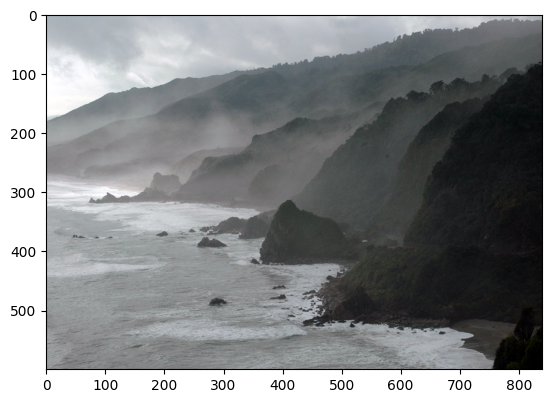

In [5]:
img_bgr = cv2.imread("New_Zealand_Coast.jpg", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

# Addition or brightness

Text(0.5, 1.0, 'Brighter Image')

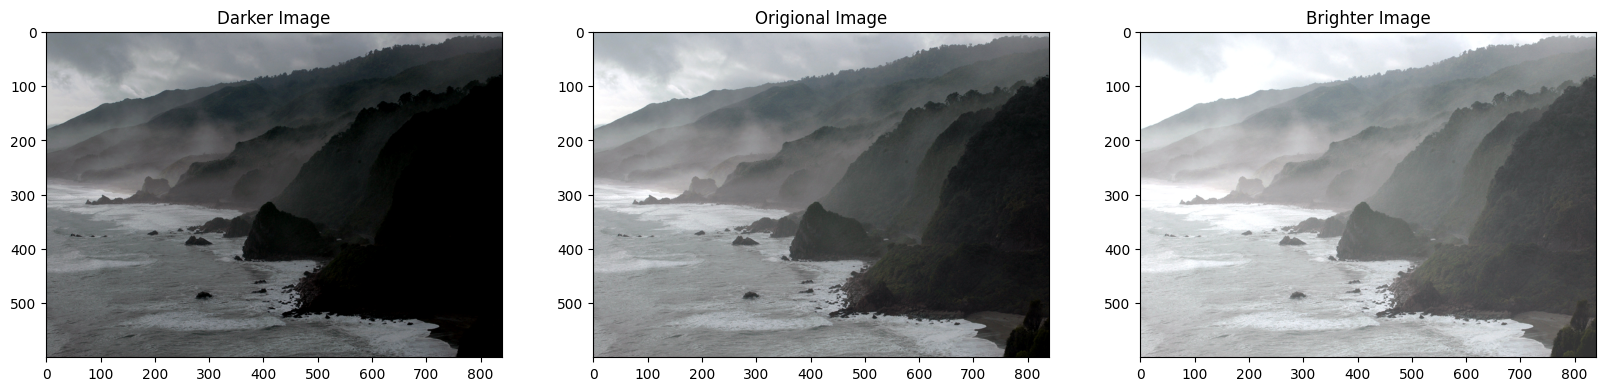

In [6]:

matrix = np.ones(img_rgb.shape, dtype = img_rgb.dtype)*50

img_rgb_brighter = cv2.add(img_rgb, matrix)

img_rgb_darker = cv2.subtract(img_rgb, matrix)

plt.figure(figsize = (20,5))

plt.subplot(131); plt.imshow(img_rgb_darker); plt.title("Darker Image")
plt.subplot(132); plt.imshow(img_rgb); plt.title("Origional Image")
plt.subplot(133); plt.imshow(img_rgb_brighter); plt.title("Brighter Image")

# Multiplication or Contrast

Text(0.5, 1.0, 'High Contrast')

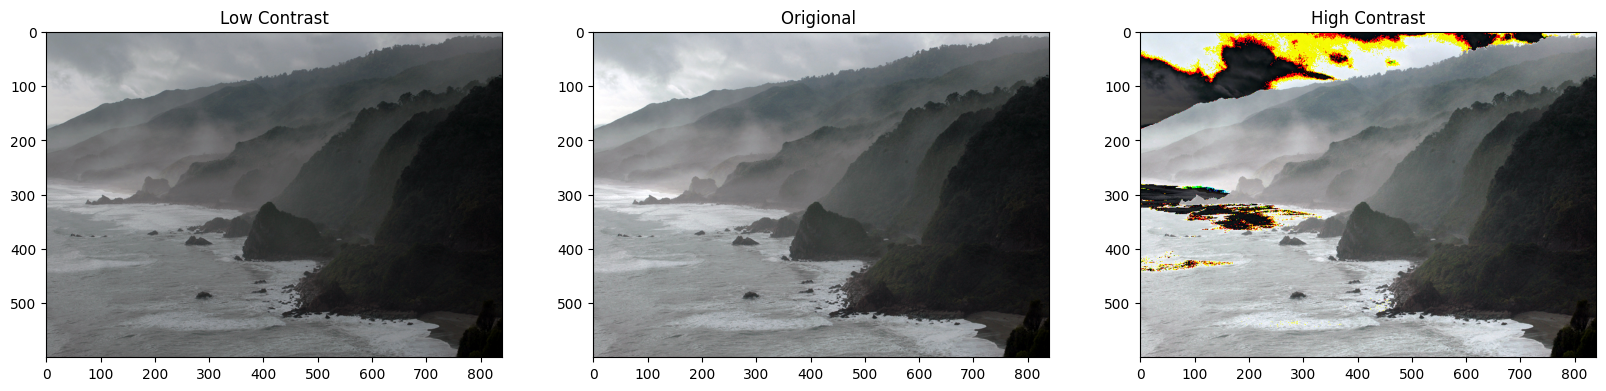

In [7]:
matrix1 = np.ones(img_rgb.shape, dtype = "float64")*0.8
matrix2 = np.ones(img_rgb.shape, dtype = "float64")*1.3

img_rgb_low_contrast = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_high_contrast = np.uint8(cv2.multiply(np.float64(img_rgb), matrix2))

plt.figure(figsize = (20,5))
plt.subplot(131); plt.imshow(img_rgb_low_contrast); plt.title("Low Contrast")
plt.subplot(132); plt.imshow(img_rgb); plt.title("Origional ")
plt.subplot(133); plt.imshow(img_rgb_high_contrast); plt.title("High Contrast")

# Handling the overflow in multiplication 

Text(0.5, 1.0, 'High Contrast ')

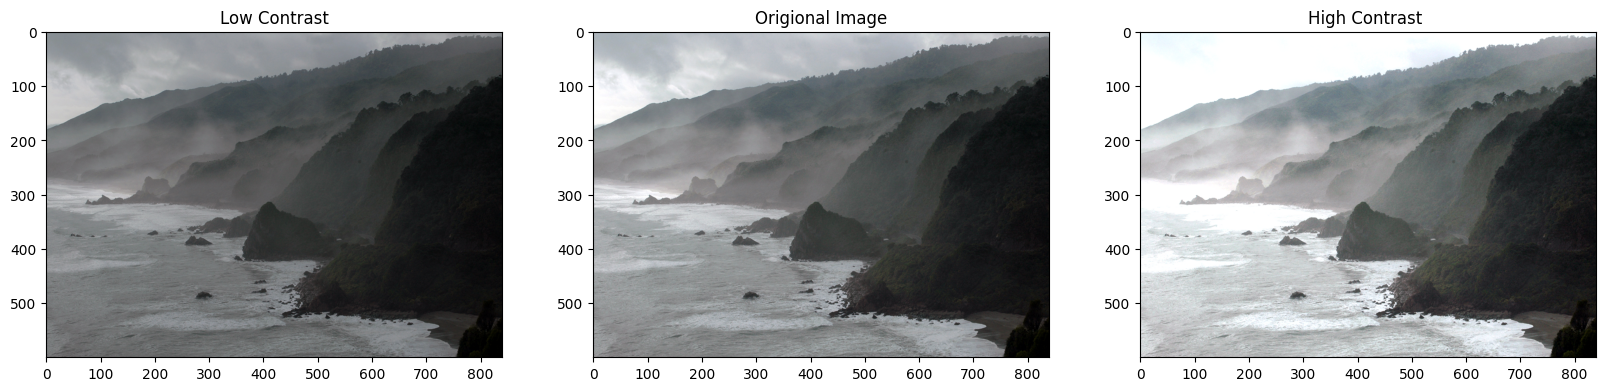

In [8]:
matrix1 = np.ones(img_rgb.shape)*0.8
matrix2 = np.ones(img_rgb.shape)*1.4

img_rgb_low_contrast = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_high_contrast = np.uint8(np.clip(cv2.multiply(np.float64(img_rgb), matrix2), 0, 255))

plt.figure(figsize = [20,5])
plt.subplot(131); plt.imshow(img_rgb_low_contrast); plt.title("Low Contrast")
plt.subplot(132); plt.imshow(img_rgb); plt.title("Origional Image")
plt.subplot(133); plt.imshow(img_rgb_high_contrast); plt.title("High Contrast ")

# Image Thresholding

Text(0.5, 1.0, 'Thresholded')

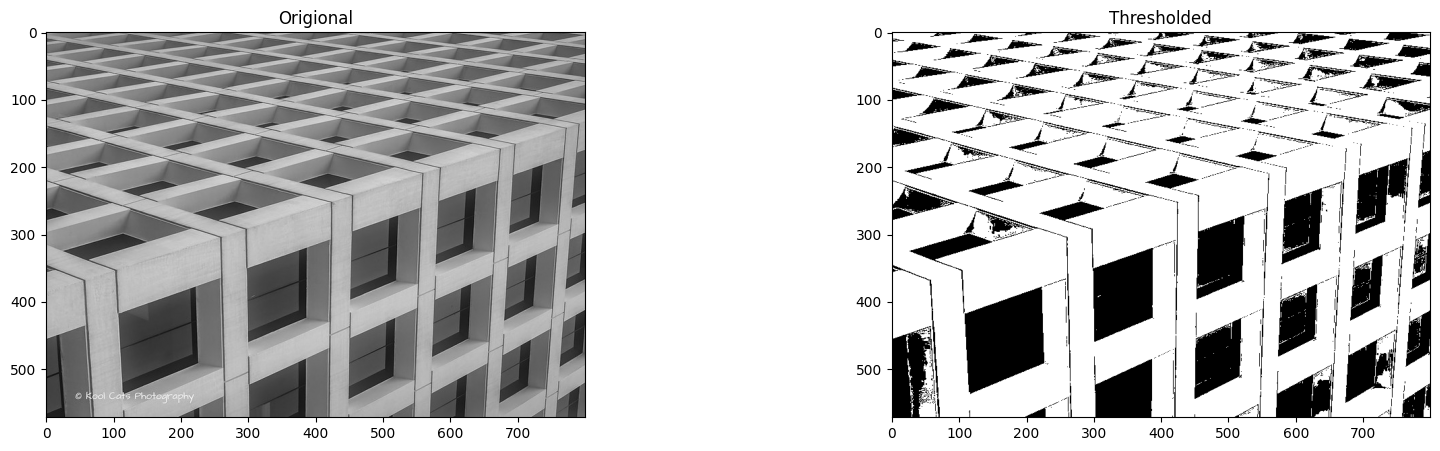

In [9]:
img_read = cv2.imread("building-windows.jpg", cv2.IMREAD_GRAYSCALE)
retval, img_thresh = cv2.threshold(img_read, 100, 255, cv2.THRESH_BINARY)

plt.figure(figsize = [20,5])
plt.subplot(121); plt.imshow(img_read, cmap = "gray"); plt.title("Origional")

plt.subplot(122); plt.imshow(img_thresh, cmap = "gray"); plt.title("Thresholded")

# Application

Text(0.5, 1.0, 'Adaptive Thresholded')

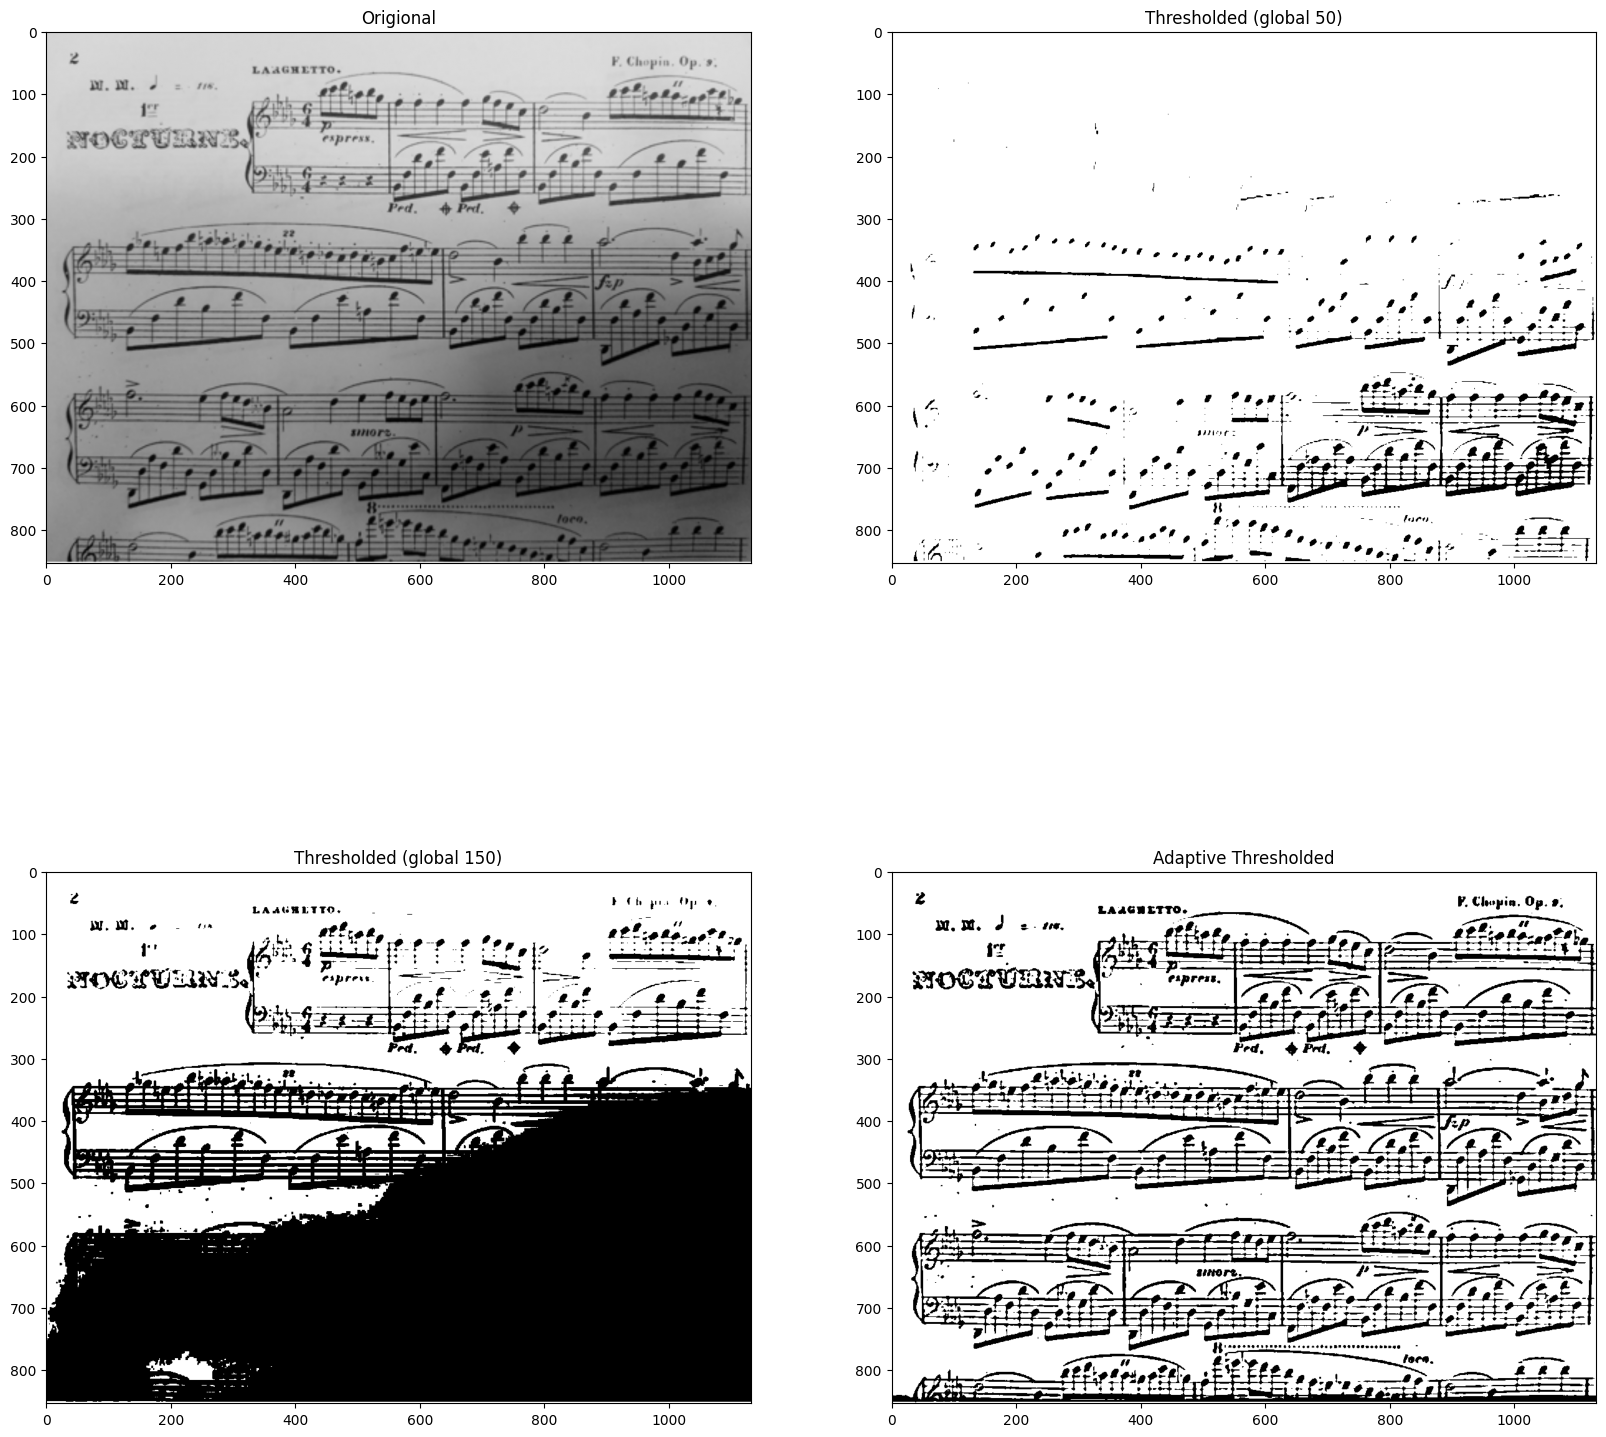

In [10]:
img_read = cv2.imread("Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)
retval, img_thresh_gb1 = cv2.threshold(img_read, 50, 255, cv2.THRESH_BINARY)
retval, img_thresh_gb2 = cv2.threshold(img_read, 150, 255, cv2.THRESH_BINARY)
img_thresh_adaptive = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,51,10)

plt.figure(figsize = [20,20])
plt.subplot(221); plt.imshow(img_read, cmap = "gray"); plt.title("Origional")
plt.subplot(222); plt.imshow(img_thresh_gb1, cmap = "gray"); plt.title("Thresholded (global 50)")
plt.subplot(223); plt.imshow(img_thresh_gb2, cmap = "gray"); plt.title("Thresholded (global 150)")
plt.subplot(224); plt.imshow(img_thresh_adaptive, cmap = "gray"); plt.title("Adaptive Thresholded") 

# Bitwise Operations

Text(0.5, 1.0, 'Circle')

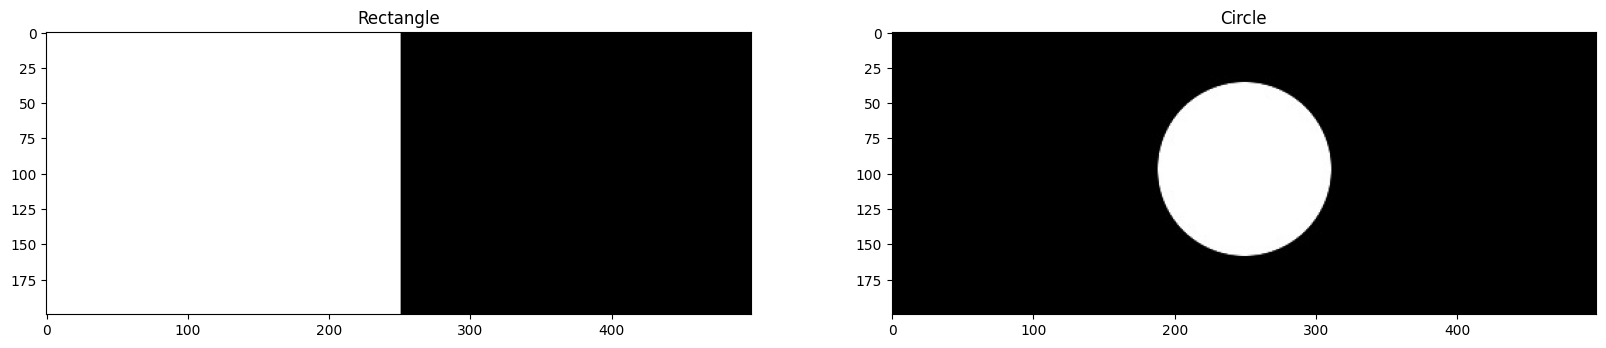

In [11]:
img_rec = cv2.imread("rectangle.jpg", cv2.IMREAD_GRAYSCALE)
img_cir = cv2.imread("circle.jpg", cv2.IMREAD_GRAYSCALE)
plt.figure(figsize = [20,5])
plt.subplot(121); plt.imshow(img_rec, cmap = "gray"); plt.title("Rectangle")
plt.subplot(122); plt.imshow(img_cir, cmap = "gray"); plt.title("Circle")

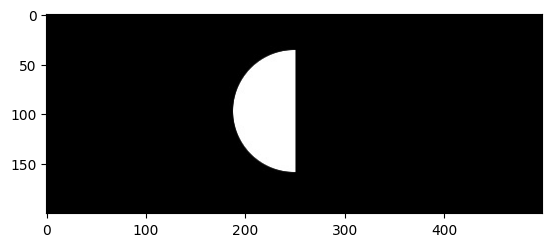

In [12]:
result = cv2.bitwise_and(img_rec, img_cir, mask = None)
plt.imshow(result, cmap = "gray")

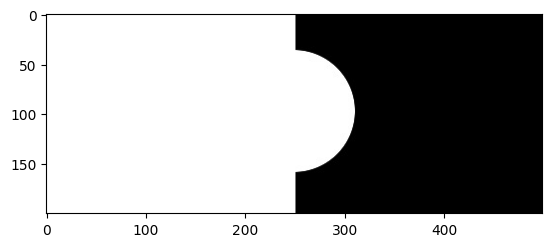

In [13]:
result = cv2.bitwise_or(img_rec, img_cir, mask = None)
plt.imshow(result, cmap = "gray" )

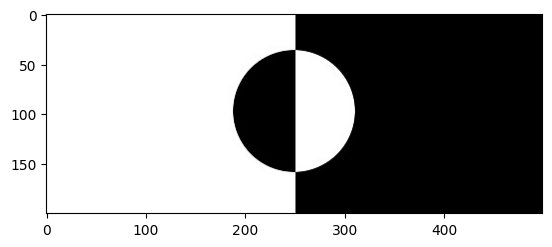

In [14]:
result = cv2.bitwise_xor(img_rec, img_cir, mask = None)
plt.imshow(result, cmap = "gray")

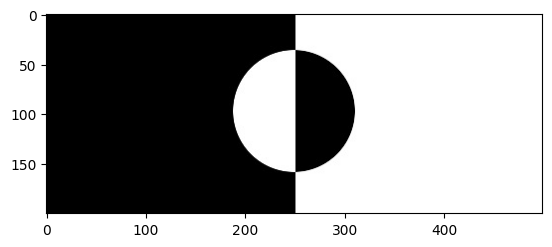

In [15]:
result_n = cv2.bitwise_not(result, mask = None)
plt.imshow(result_n, cmap = "gray")

## applying mask

In [16]:
mask = np.zeros(img_rec.shape, dtype = "uint8")
mask[20:180, 100:400] = 255
print(img_rec.shape, img_cir.shape)

(200, 499) (200, 499)


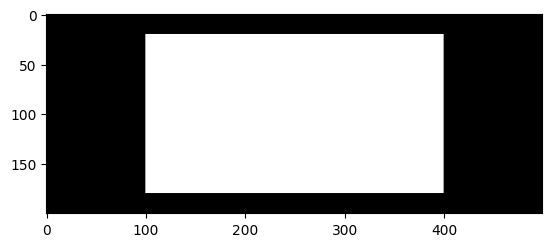

In [17]:
plt.imshow(mask, cmap = "gray")

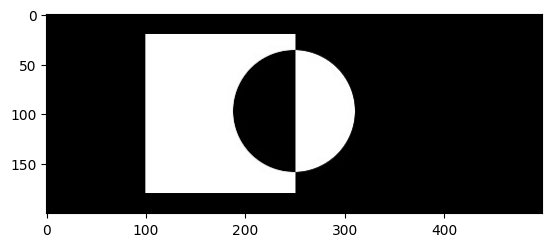

In [18]:
result = cv2.bitwise_xor(img_rec, img_cir, mask = mask)
plt.imshow(result, cmap = "gray")

# Application : Logo Manipulation

(700, 700, 3)
Logo width: 700
Logo Height: 700


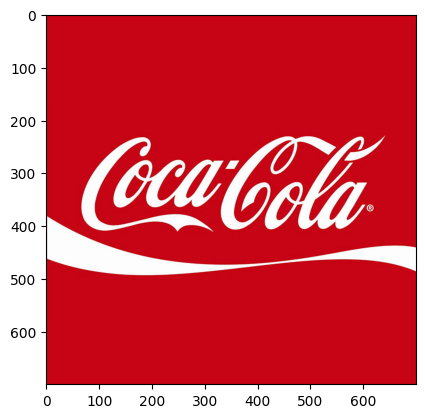

In [19]:
img_bgr = cv2.imread("coca-cola-logo.png", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
print(img_rgb.shape)
print("Logo width:", img_rgb.shape[1])
print("Logo Height:", img_rgb.shape[0])

## Background Image

(1800, 1800, 3)
Background Width 1800
Background Height 1800


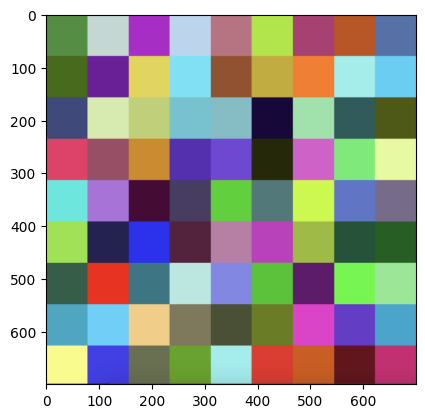

In [20]:
img_background_bgr = cv2.imread("checkerboard_color.png", cv2.IMREAD_COLOR)
img_background_rgb = cv2.cvtColor(img_background_bgr, cv2.COLOR_BGR2RGB)
print(img_background_rgb.shape)
print("Background Width",img_background_rgb.shape[1])
print("Background Height", img_background_rgb.shape[0])
dim = (700,700)
img_background_rgb_resized = cv2.resize(img_background_rgb, dim, interpolation = cv2.INTER_AREA)
plt.imshow(img_background_rgb_resized)

 ## creating mask

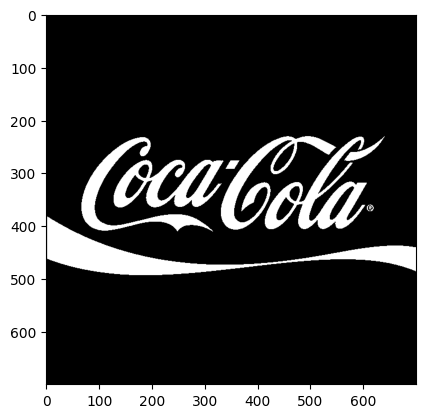

In [21]:
img_coke_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

retval, img_mask = cv2.threshold(img_coke_gray,100, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(img_mask, cmap = "gray")

## Inverted mask

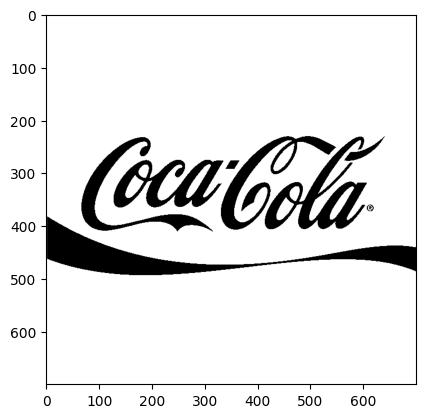

In [22]:
img_mask_inv = cv2.bitwise_not(img_mask, mask = None)
plt.imshow(img_mask_inv, cmap = "gray")

## Apply background on the mask

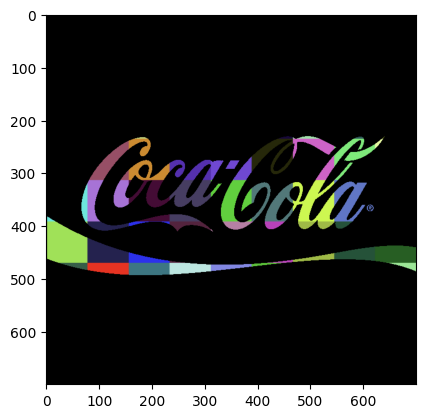

In [23]:
img_background = cv2.bitwise_and(img_background_rgb_resized, img_background_rgb_resized, mask = img_mask)
plt.imshow(img_background)

## Isolating the foreground

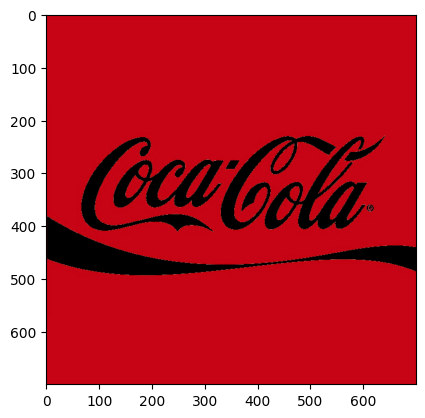

In [24]:
img_foreground = cv2.bitwise_and(img_rgb, img_rgb, mask = img_mask_inv)
plt.imshow(img_foreground)

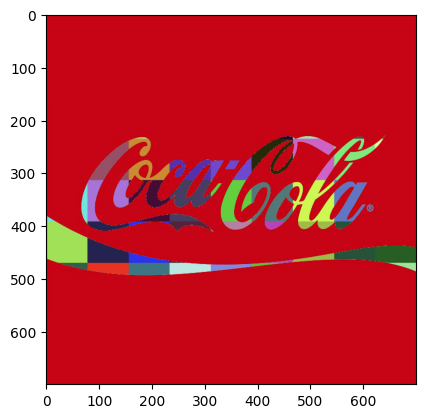

In [25]:
final_result = cv2.add(img_background, img_foreground)
plt.imshow(final_result)

In [26]:
! git checkout module-04

Already on 'module-04'


In [27]:
! git status

On branch module-04
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Logo_Manipulation.png
	New_Zealand_Coast.jpg
	Piano_Sheet_Music.png
	building-windows.jpg
	car_reflection.jpg
	checkerboard_color.png
	circle.jpg
	coca-cola-logo.png
	module-04.ipynb
	opencv_bootcamp_assets_NB1.zip
	opencv_bootcamp_assets_NB2.zip
	opencv_bootcamp_assets_NB3.zip
	opencv_bootcamp_assets_NB4.zip
	rectangle.jpg

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
! git add module-04.ipynb rectangle.jpg coca-cola-logo.png